# Identifying fish with contrastive

We will demonstrate that an embedding CNN (ResNet18) can be trained to differentiate fish images from various animals. For this, we will use miniCARP, a simplified version of a fish image library developed by the lab as part of the idtracker.ai 2019 paper.

In [1]:
import random
from pathlib import Path
from random import randint

import gdown
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from torch import Tensor
from torch.nn.functional import pairwise_distance, relu
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision.models.resnet import BasicBlock, ResNet
from tqdm.notebook import trange

if torch.cuda.is_available():
    print("GPU is enabled.")
    DEVICE = torch.device("cuda")
else:
    print("WARNING: GPU is not enabled in this environment.")
    DEVICE = torch.device("cpu")

GPU is enabled.


Let's start by downloading the miniCARP dataset.

In [2]:
CARP_PATH = Path("./miniCARP/")


def download_carp() -> None:
    if not CARP_PATH.is_dir():
        CARP_PATH.mkdir()
        gdown.download(
            id="19u3X339wNDOYgTr4AZp-L8O_7F5I82Wp",
            output=str(CARP_PATH / "miniCARP_images.npy"),
        )
        gdown.download(
            id="1NeULdkj6HrPw8inKHJ4Sqhnts_6KDcik",
            output=str(CARP_PATH / "miniCARP_labels.npy"),
        )


def load_carp(fraction: float) -> tuple[Tensor, Tensor]:
    images: np.ndarray = np.load(CARP_PATH / "miniCARP_images.npy")
    labels: np.ndarray = np.load(CARP_PATH / "miniCARP_labels.npy")
    num_images = int(np.floor(images.shape[0] * fraction))
    return torch.from_numpy(images[:num_images]), torch.from_numpy(labels[:num_images])


download_carp()
all_images, all_labels = load_carp(fraction=0.1)
all_images = all_images.unsqueeze(1) / 255

Let's get some information about the dataset.

In [3]:
print(f"Images shape: {all_images.shape}, dtype: {all_images.dtype}")
print(f"Labels shape: {all_labels.shape}, dtype: {all_labels.dtype}")
print(f"Label options: {torch.unique(all_labels).tolist()}")
NUM_LABELS = len(torch.unique(all_labels))

Images shape: torch.Size([7500, 1, 52, 52]), dtype: torch.float32
Labels shape: torch.Size([7500]), dtype: torch.uint8
Label options: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


We loaded 7500 images of size 52x52 corresponding to 15 different individuals, numbered 0-14. Here, we print some examples, together with the labels. Feel free to change the range of images and labels to be shown.

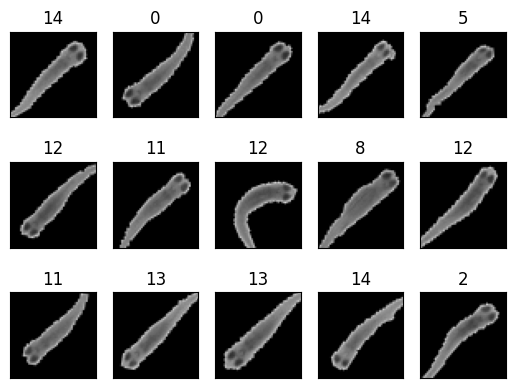

In [4]:
def show_images(images, labels=None):
    fig, axes = plt.subplots(3, len(images) // 3)
    for image, ax in zip(images, axes.flatten()):
        ax.imshow(image[0].numpy(), cmap="binary_r", vmax=1)
        ax.set(xticks=(), yticks=())
    if labels is not None:
        for label, ax in zip(labels, axes.flatten()):
            ax.set(title=label.item())
    plt.show()


# Change range here to print other images
index = randint(0, len(all_images) - 15)
show_images(all_images[index : index + 15], labels=all_labels[index : index + 15])

We divide the dataset into disjoint train/test datasets.

In [5]:
test_size = 1000
labels = {"train": all_labels[:-test_size], "test": all_labels[-test_size:]}
images = {"train": all_images[:-test_size], "test": all_images[-test_size:]}

print(
    "Train and test are fractions {:.2%} and {:.2%}".format(
        len(images["train"]) / len(all_images), len(images["test"]) / len(all_images)
    )
)

Train and test are fractions 86.67% and 13.33%


We use a custom Dataset to generate one positive and one negative pair of images with each `__getitem__` call. Positive pairs consist of images sampled from the same class, while negative pairs are drawn from different classes.

In [6]:
class PairsDataset(Dataset):
    def __init__(self, images: Tensor, labels: Tensor):
        self.images = images
        self.labels = labels
        self.max_label = int(labels.max())
        self.images_per_class = {
            label: images[labels == label] for label in range(self.max_label + 1)
        }

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        positive_label = random.randint(0, self.max_label)
        negative_label_a, negative_label_b = random.sample(range(self.max_label + 1), 2)
        images = random.choices(self.images_per_class[positive_label], k=2) + [
            random.choice(self.images_per_class[negative_label_a]),
            random.choice(self.images_per_class[negative_label_b]),
        ]
        return images

Let's set up the DataLoaders:  
- `train_dataloader`: This will supply positive and negative pairs of images for training the network.  
- `val_dataloader`: This will provide the same images as the training set but in a naive, flat structure. It will be used to compute the Silhouette score during training.  
- `test_dataloader`: This will provide test images in a flat structure, similar to the validation DataLoader, for evaluation.

In [7]:
train_dataloader = DataLoader(
    PairsDataset(images["train"], labels["train"]),
    batch_size=400,
    num_workers=3,
    persistent_workers=True,
)
val_dataloader = DataLoader(
    TensorDataset(images["train"], labels["train"]),
    batch_size=400,
    num_workers=3,
    persistent_workers=True,
)
test_dataloader = DataLoader(
    TensorDataset(images["test"], labels["test"]),
    batch_size=400,
    num_workers=3,
    persistent_workers=True,
)

We use ResNet18 as our embedding network, incorporating two modifications to the [standard PyTorch implementation](https://pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html):
1. The first layer is adjusted to accept single-channel tensors for grayscale images.
2. The final layer is configured to have 8 neurons by setting `num_classes=8`, creating an 8-dimensional representation space.

In [8]:
# from idtrackerai.base.network import ResNet18 # the network is originally defined in idtrackerai


class ResNet18(ResNet):
    def __init__(self, n_channels_in: int = 1, n_dimensions_out: int = 8) -> None:
        super().__init__(BasicBlock, [2, 2, 2, 2], num_classes=n_dimensions_out)
        if n_channels_in != 3:
            # adapt first conv layer to our single channel images (not RGB)
            self.conv1 = torch.nn.Conv2d(
                n_channels_in, 64, kernel_size=7, stride=2, padding=3, bias=False
            )


resnet = ResNet18().to(DEVICE)
optimizer = torch.optim.Adam(resnet.parameters(), lr=0.001)

print(resnet)
print(sum(p.numel() for p in resnet.parameters()) / 1.0e6, "M parameters")

ResNet18(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)


The [Silhouette score](https://en.wikipedia.org/wiki/Silhouette_(clustering)) is a measure of how close a datapoint is to its own cluster (cohesion) compared to other clusters (separation). This score increases with the definition of the clusters in our representation space.

In [9]:
# from idtrackerai.base.tracker.contrastive import silhouette_scores # the silhouette_scores function is originally defined in idtrackerai


def silhouette_scores(X: Tensor, labels: Tensor) -> Tensor:
    """Silhouette score implemented in PyTorch for GPU acceleration

    .. seealso::

        `Wikipedia's entry on Silhouette score <https://en.wikipedia.org/wiki/Silhouette_(clustering)>`_

    Parameters
    ----------
    X : Tensor
        Data points of shape (n_samples, n_features)
    labels : Tensor
        Predicted label for each sample, shape (n_samples)

    Returns
    -------
    Tensor
        Silhouette score for each sample, shape (n_samples). Same device and dtype as X
    """
    unique_labels = torch.unique(labels)

    intra_dist = torch.zeros(labels.size(), dtype=X.dtype, device=X.device)
    for label in unique_labels:
        where = labels == label
        X_where = X[where]
        distances = torch.cdist(X_where, X_where)
        intra_dist[where] = distances.sum(dim=1) / (len(distances) - 1)

    inter_dist = torch.full(labels.size(), torch.inf, dtype=X.dtype, device=X.device)

    for label_a, label_b in torch.combinations(unique_labels, 2):
        where_a = labels == label_a
        where_b = labels == label_b

        dist = torch.cdist(X[where_a], X[where_b])
        dist_a = dist.mean(dim=1)
        dist_b = dist.mean(dim=0)

        inter_dist[where_a] = torch.minimum(dist_a, inter_dist[where_a])
        inter_dist[where_b] = torch.minimum(dist_b, inter_dist[where_b])

    sil_samples = (inter_dist - intra_dist) / torch.maximum(intra_dist, inter_dist)

    return sil_samples.nan_to_num()

In [10]:
def contrastive_loss_function(
    pos_embs_A: Tensor, pos_embs_B: Tensor, neg_embs_A: Tensor, neg_embs_B: Tensor
) -> Tensor:
    positive_distance = pairwise_distance(pos_embs_A, pos_embs_B)
    positive_loss = relu(positive_distance - 1).square().sum()

    negative_distance = pairwise_distance(neg_embs_A, neg_embs_B)
    negative_loss = relu(10 - negative_distance).square().sum()

    return positive_loss + negative_loss

Lets train!

In [11]:
train_loss = []
silhouettes = []
best_silhouette = 0

for _ in trange(40, desc="Training"):
    running_loss = 0.0

    resnet.train()
    # Train on a batch of images
    for pos_imgs_A, pos_imgs_B, neg_imgs_A, neg_imgs_B in train_dataloader:
        optimizer.zero_grad(set_to_none=True)
        pos_imgs_A = pos_imgs_A.to(DEVICE, non_blocking=True)
        pos_imgs_B = pos_imgs_B.to(DEVICE, non_blocking=True)
        neg_imgs_A = neg_imgs_A.to(DEVICE, non_blocking=True)
        neg_imgs_B = neg_imgs_B.to(DEVICE, non_blocking=True)

        pos_embs_A = resnet(pos_imgs_A)
        pos_embs_B = resnet(pos_imgs_B)
        neg_embs_A = resnet(neg_imgs_A)
        neg_embs_B = resnet(neg_imgs_B)

        total_loss = contrastive_loss_function(
            pos_embs_A, pos_embs_B, neg_embs_A, neg_embs_B
        )
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()

    train_loss.append(running_loss / len(train_dataloader))

    resnet.eval()
    with torch.inference_mode():
        embeddings = torch.concatenate(
            [resnet(images.to(DEVICE)) for (images, _labels) in val_dataloader]
        ).detach()
        kmeans = MiniBatchKMeans(n_clusters=NUM_LABELS)
        labels = torch.from_numpy(kmeans.fit_predict(embeddings.numpy(force=True)))
        silhouette = silhouette_scores(embeddings, labels.to(DEVICE)).mean().item()
    if silhouette > best_silhouette:
        best_silhouette = silhouette
        torch.save(resnet.state_dict(), "checkpoint.pt")
        print(f"Best silhouette: {best_silhouette:.4f}")
    silhouettes.append(silhouette)
resnet.load_state_dict(torch.load("checkpoint.pt", weights_only=True))
Path("checkpoint.pt").unlink()
print(f"Loaded best model with silhouette: {best_silhouette:.4f}")

Training:   0%|          | 0/40 [00:00<?, ?it/s]

Best silhouette: 0.2467
Best silhouette: 0.2833
Best silhouette: 0.3005
Best silhouette: 0.3695
Best silhouette: 0.4218
Best silhouette: 0.4476
Best silhouette: 0.5794
Best silhouette: 0.6316
Best silhouette: 0.6359
Best silhouette: 0.7191
Best silhouette: 0.7539
Best silhouette: 0.7689
Best silhouette: 0.8047
Best silhouette: 0.8284
Best silhouette: 0.8490
Best silhouette: 0.9127
Best silhouette: 0.9210
Best silhouette: 0.9265
Loaded best model with silhouette: 0.9265


Observe how the loss decreases and the Silhouette score increases during training. Due to the instability in cluster shapes (as indicated by the frequent drops in the Silhouette score), we use checkpoints to reload the network with the highest Silhouette score.

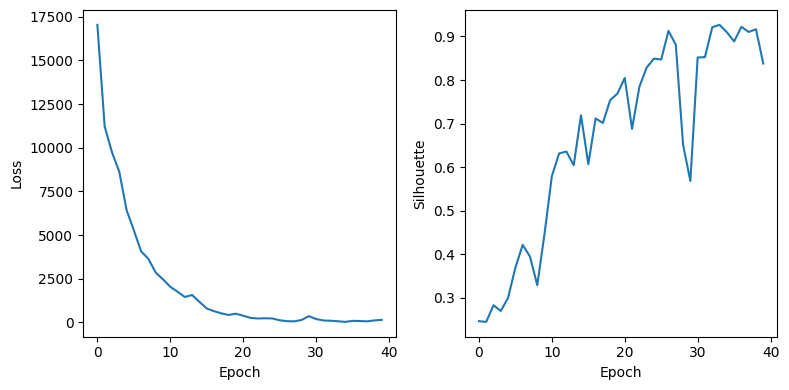

In [12]:
fig, (ax_loss, ax_silhouettes) = plt.subplots(1, 2, figsize=(8, 4))
ax_loss.plot(train_loss)
ax_silhouettes.plot(silhouettes)
ax_loss.set(ylabel="Loss", xlabel="Epoch")
ax_silhouettes.set(ylabel="Silhouette", xlabel="Epoch")
fig.tight_layout()

Let's examine the clustering results for the training dataset. Since the cluster identities may not align with the ground truth, we will permute them to ensure they match.

In [13]:
plt.style.use("dark_background")


def evaluate_predictions(
    gt_labels: np.ndarray, predicted_labels: np.ndarray, tsne: np.ndarray
):
    """Evaluate the predictions and plot the confusion matrix and t-SNE embeddings"""
    confusion = confusion_matrix(gt_labels, predicted_labels)
    ids, matches = linear_sum_assignment(-confusion.T)

    fig, (confusion_ax, ground_truth_ax, prediction_errors_ax) = plt.subplots(
        1, 3, figsize=(13, 5)
    )
    confusion_ax.set_title("Confusion matrix")
    ground_truth_ax.set_title("Ground truth")
    prediction_errors_ax.set_title("Error")

    confusion_ax.imshow(confusion, interpolation="none")
    confusion_ax.plot(ids, matches, "ro", label="Identity matching")
    confusion_ax.legend()
    confusion_ax.set(xlabel="Predicted", ylabel="Ground truth")
    confusion_ax.set(xticks=range(NUM_LABELS), yticks=range(NUM_LABELS))

    print(f"Accuracy: {confusion[matches, ids].sum() / len(gt_labels):.2%}")
    matched_labels = np.asarray([matches[label] for label in predicted_labels])

    for confusion_ax in (ground_truth_ax, prediction_errors_ax):
        confusion_ax.set_aspect("equal")
        confusion_ax.set(xticks=(), yticks=())

    ground_truth_ax.scatter(
        *tsne.T, c=(gt_labels / np.max(gt_labels) + 1), cmap="hsv", s=3, lw=0
    )
    prediction_errors_ax.scatter(
        *tsne.T,
        c=(gt_labels == matched_labels),
        cmap="RdYlGn",
        s=3,
        lw=0,
        vmin=0,
        vmax=1,
    )
    fig.tight_layout()

Accuracy: 99.85%


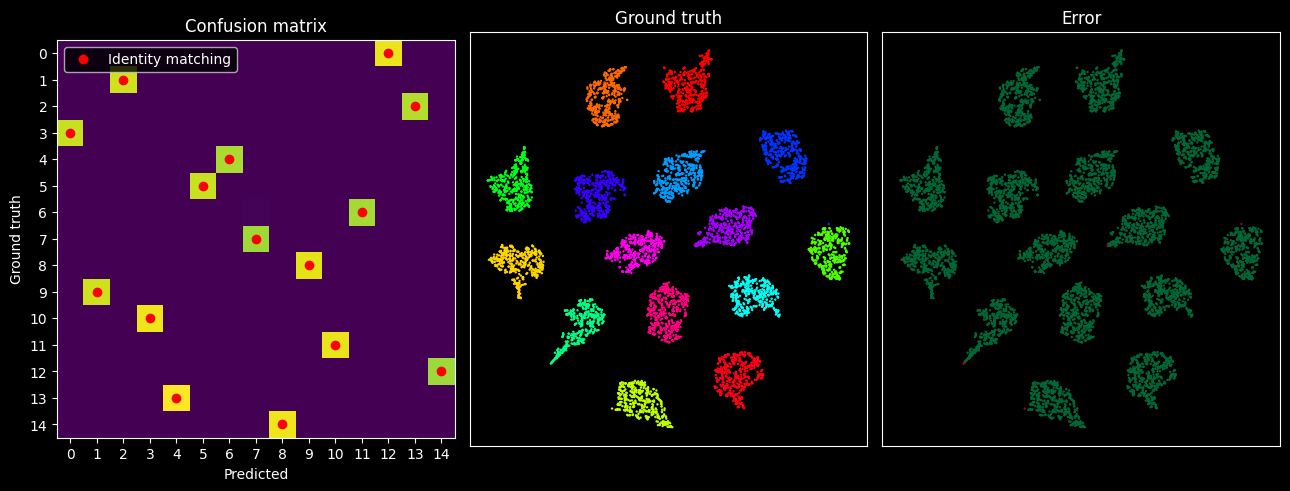

In [14]:
with torch.inference_mode():
    embeddings = []
    labels = []
    for images, _labels in val_dataloader:
        labels.append(_labels)
        embeddings.append(resnet(images.to(DEVICE)).numpy(force=True))
    gt_labels = np.concatenate(labels)
    embeddings = np.concatenate(embeddings)
    kmeans = MiniBatchKMeans(n_clusters=NUM_LABELS)
    predicted_labels = kmeans.fit_predict(embeddings)

tsne = TSNE(n_jobs=4).fit_transform(embeddings)
evaluate_predictions(gt_labels, predicted_labels, tsne)

Now, let's evaluate on the test dataset. These images have not been seen by the network during training. We will assign images to clusters by using the cluster centers obtained from the training step.

Accuracy: 93.90%


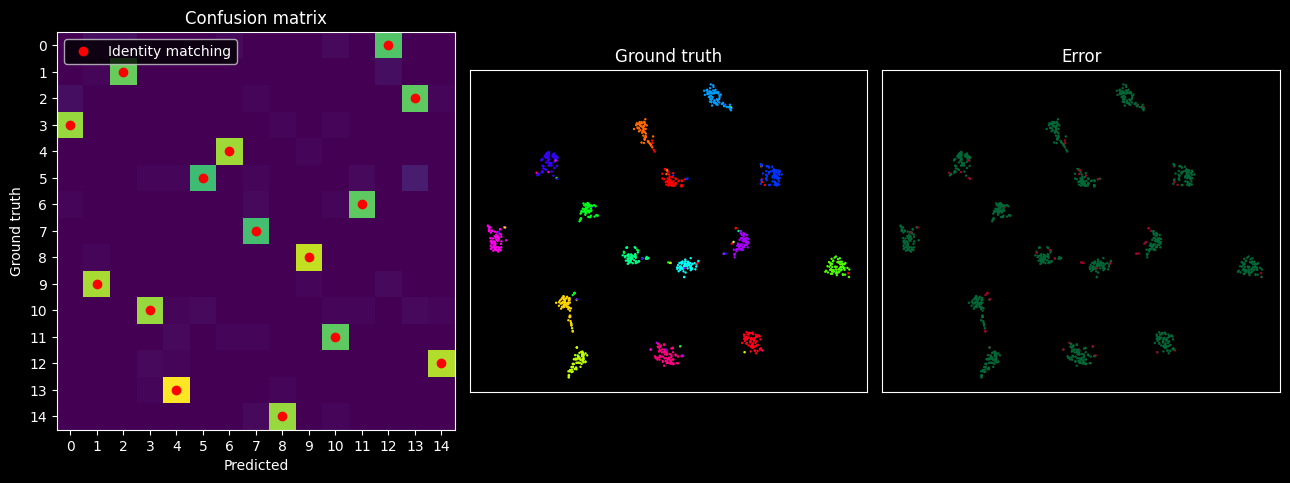

In [15]:
with torch.inference_mode():
    embeddings = []
    labels = []
    for images, _labels in test_dataloader:
        labels.append(_labels)
        embeddings.append(resnet(images.to(DEVICE)).numpy(force=True))
    gt_labels = np.concatenate(labels)
    embeddings = np.concatenate(embeddings)
    # get predicted labels from previous cluster centers
    predicted_labels = kmeans.predict(embeddings)

tsne = TSNE(n_jobs=4).fit_transform(embeddings)
evaluate_predictions(gt_labels, predicted_labels, tsne)

It's important to note that when tracking a video, all images are used to train the embedding network, so there is no separate test dataset. Additionally, positive and negative pairs are not generated from labeled ground truth, as such labels do not exist in this scenario. Instead, positive pairs are formed from images within the same fragment, while negative pairs are created from pairs of coexisting fragments.